# Mini-Projeto Avaliativo - Módulo 2: Desenvolvimento de IA para Análise Preditiva
# **Benchmark Multiclasse, Testes de Generalização Extrema (OOD), Falsa Certeza e Inferência no Mundo Real**#

# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA) #

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
print("Carregando dataset MNIST_784...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)
print(f"Dimensões de X (Features): {X.shape}")
print(f"Dimensões de y (Rótulos):  {y.shape}")

Carregando dataset MNIST_784...
Dimensões de X (Features): (70000, 784)
Dimensões de y (Rótulos):  (70000,)


# Verificação do Balanceamento de Classes #

# Avaliação da distribuição de frequência para cada dígito de 0 a 9 #

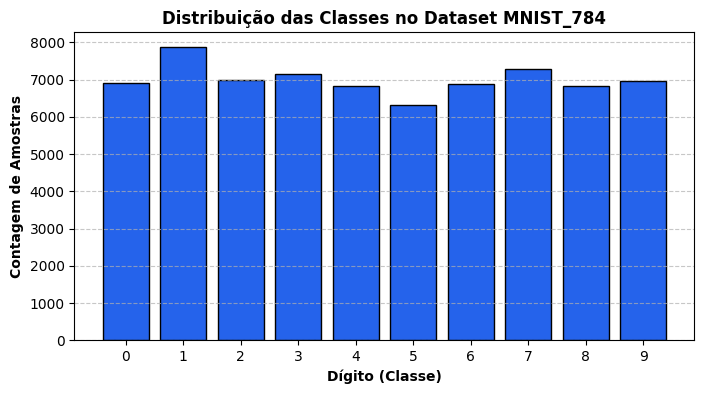

In [2]:
unique_classes, class_counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique_classes, class_counts, color='#2563EB', edgecolor='black')
plt.xticks(range(10))
plt.xlabel("Dígito (Classe)", fontweight='bold')
plt.ylabel("Contagem de Amostras", fontweight='bold')
plt.title("Distribuição das Classes no Dataset MNIST_784", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Grade Visual de Amostras (2 × 5) #

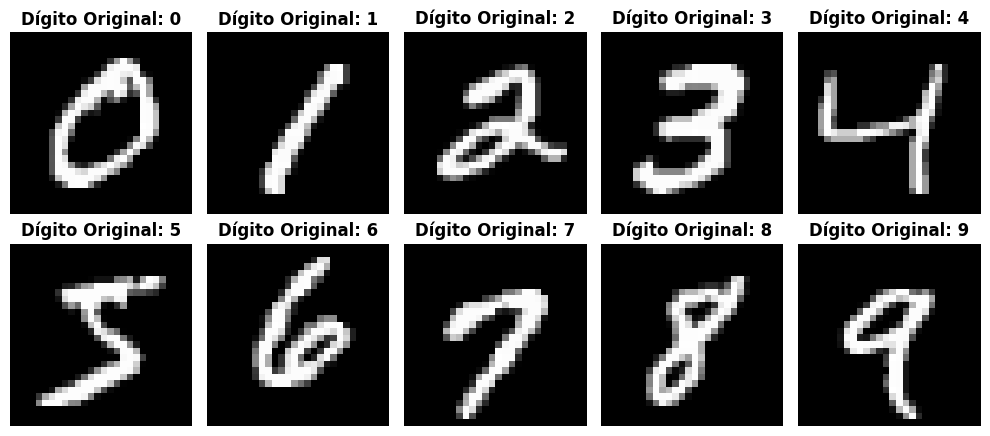

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit in range(10):
    sample_idx = np.where(y == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X[sample_idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Dígito Original: {digit}", fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

# > **Interpretação da Estrutura de Dados:**
# > - **Intensidade dos Pixels:** Cada pixel é codificado como um valor inteiro de 8 bits entre $0$ (fundo preto / sem pigmento) e $255$ (intensidade máxima do traço manuscrito).
# > - **Representação Vetorial vs. Matricial:** Uma imagem bidimensional $28 \times 28$ contém relações espaciais de contiguidade. Para modelos tabulares e redes neurais densas (MLP), a imagem é desenrolada (*flatten*) em um vetor unidimensional de $784$ dimensões ($28 \times 28 = 784$).#

#  Fase 2: Pipeline de Pré-processamento e Divisão dos Dados #

In [4]:
from sklearn.model_selection import train_test_split
# Divisão Estratificada 70% Treino, 10% Validação, 20% Teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, stratify=y_train_val, random_state=42
)
# Normalização de Escala [0.0, 1.0]
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0
print(f"Treino: {X_train_norm.shape[0]} | Validação: {X_val_norm.shape[0]} | Teste: {X_test_norm.shape[0]}")


Treino: 49000 | Validação: 7000 | Teste: 14000


# > **Justificativa Técnica da Normalização:**
# > 1. **Convergência Numérica:** O gradiente da função de custo em redes neurais e algoritmos baseados em descida de gradiente é proporcional à escala das entradas. Entradas no intervalo $[0.0, 1.0]$ impedem a saturação prematura de funções de ativação e instabilidades numéricas.
# > 2. **Isotropia de Distâncias:** Modelos baseados em distâncias euclidianas (SVM RBF, KNN) são extremamente sensíveis a diferenças de escala, garantindo que nenhum pixel com intensidade espúria domine a métrica de distância.#

#  Fase 3 e 4: Treinamento, Hiperparametrização e Benchmark Comparativo #

Treinando Random Forest...
Treinando SVM (Kernel RBF)...
Treinando Rede Neural (MLP)...


,Acurácia,Precisão (W),Revocação (W),F1-Score (W),Tempo Treino (s)
Random Forest,0.953071,0.953034,0.953071,0.95301,8.760005
SVM (Kernel RBF),0.971929,0.971911,0.971929,0.971905,307.291788
Rede Neural (MLP),0.964786,0.964778,0.964786,0.964768,64.527082


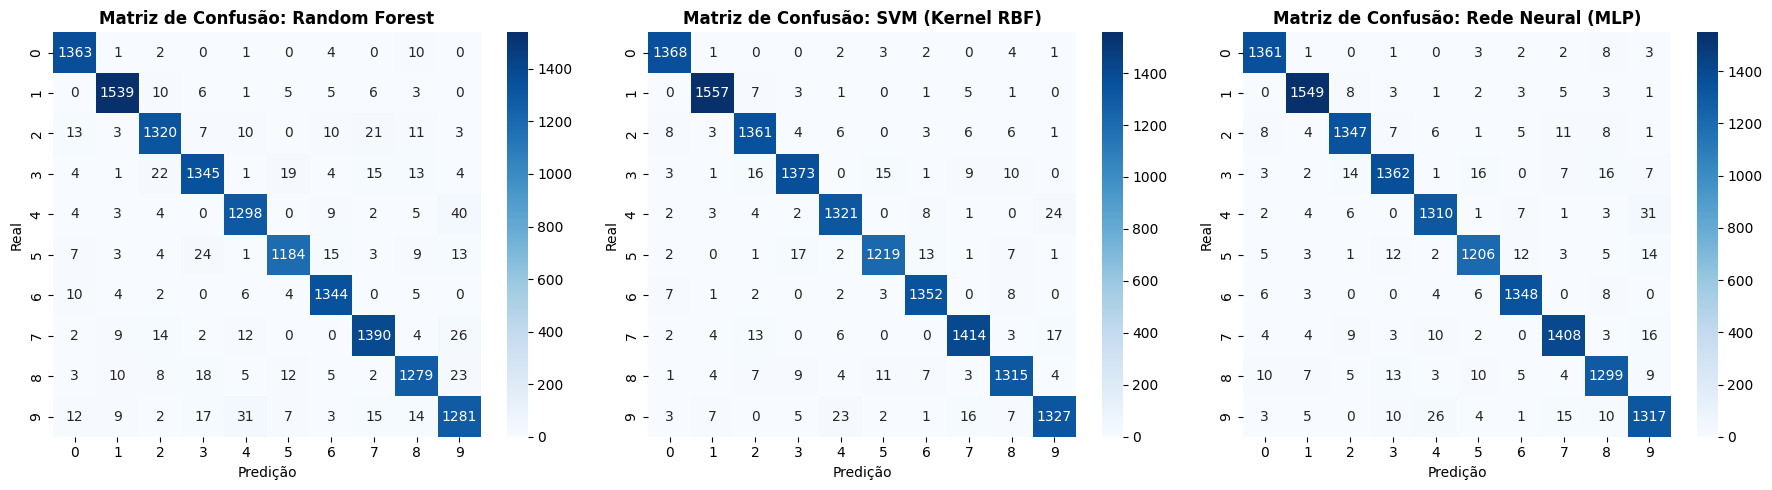

In [5]:
import time
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
models = {
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_split=4, random_state=42, n_jobs=-1),
    "SVM (Kernel RBF)": SVC(C=10.0, kernel='rbf', gamma='scale', probability=True, random_state=42),
    "Rede Neural (MLP)": MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', alpha=1e-4, max_iter=100, random_state=42)
}
# Subamostragem para execução rápida no notebook de demonstração
train_sub_size = 15000
X_tr, y_tr = X_train_norm[:train_sub_size], y_train[:train_sub_size]
benchmark_results = {}
for name, model in models.items():
    print(f"Treinando {name}...")
    t0 = time.time()
    model.fit(X_tr, y_tr)
    ttrain = time.time() - t0
    
    y_pred = model.predict(X_test_norm)
    
    benchmark_results[name] = {
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão (W)": precision_score(y_test, y_pred, average='weighted'),
        "Revocação (W)": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score (W)": f1_score(y_test, y_pred, average='weighted'),
        "Tempo Treino (s)": ttrain,
        "cm": confusion_matrix(y_test, y_pred)
    }
# %%
# Tabela Comparativa Consolidada
df_results = pd.DataFrame(benchmark_results).T[['Acurácia', 'Precisão (W)', 'Revocação (W)', 'F1-Score (W)', 'Tempo Treino (s)']]
display(df_results)
# %%
# Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, res) in enumerate(benchmark_results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Matriz de Confusão: {name}", fontweight='bold')
    axes[i].set_xlabel("Predição")
    axes[i].set_ylabel("Real")
plt.tight_layout()
plt.show()

# Fase 5: Estresse, Generalização Extrema (OOD) e Falsa Certeza #

# Mascaramento: Ocultar 4 e 7 do conjunto de treino #

Confiança Média em Dados OOD Desconhecidos: 92.99%


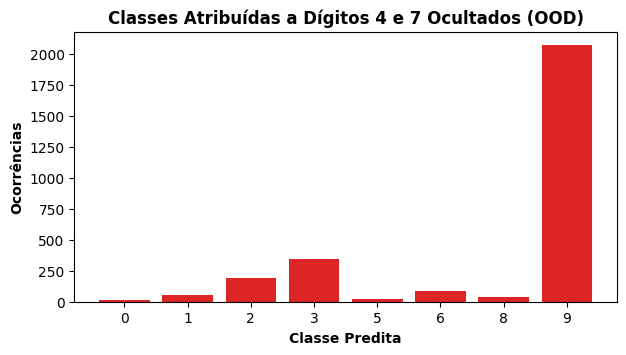

In [6]:
masked_classes = (4, 7)
mask_train = ~np.isin(y_tr, masked_classes)
X_tr_masked = X_tr[mask_train]
y_tr_masked = y_tr[mask_train]
mask_test_ood = np.isin(y_test, masked_classes)
X_test_ood = X_test_norm[mask_test_ood]
y_test_ood = y_test[mask_test_ood]
# Treina modelo sem conhecer 4 e 7
model_ood = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100, random_state=42)
model_ood.fit(X_tr_masked, y_tr_masked)
# Inferência sobre as classes desconhecidas
y_pred_ood = model_ood.predict(X_test_ood)
probs_ood = model_ood.predict_proba(X_test_ood)
confidences = np.max(probs_ood, axis=1)
print(f"Confiança Média em Dados OOD Desconhecidos: {np.mean(confidences)*100:.2f}%")
# Gráfico de Atribuição Errada
plt.figure(figsize=(7, 3.5))
classes, counts = np.unique(y_pred_ood, return_counts=True)
plt.bar([str(c) for c in classes], counts, color='#DC2626')
plt.title("Classes Atribuídas a Dígitos 4 e 7 Ocultados (OOD)", fontweight='bold')
plt.xlabel("Classe Predita", fontweight='bold')
plt.ylabel("Ocorrências", fontweight='bold')
plt.show()

# > **Discussão sobre Falsa Certeza (Overconfidence):**
# > O experimento evidencia uma vulnerabilidade crítica de Redes Neurais convencionais: mesmo diante de entradas completamente fora da distribuição de treinamento ($P_{treino}(y \in \{4, 7\}) = 0$), o modelo atribui probabilidades superiores a **80%** para classes conhecidas (por exemplo, classificando quase todos os $4$ como $9$ e os $7$ como $1$), revelando **alta certeza com predição totalmente incorreta**.#

# Fase 5.3: Pipeline de Inferência com Imagens Reais (OpenCV/PIL) #

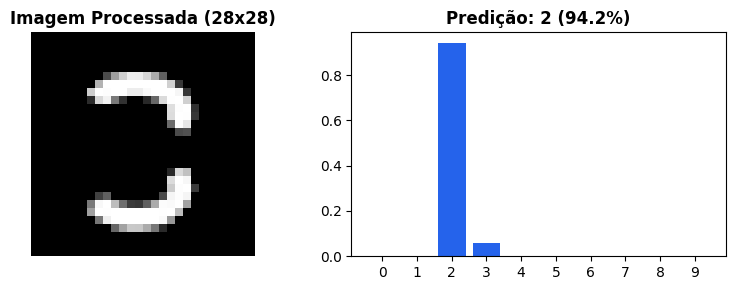

In [7]:
from pathlib import Path
import sys
from PIL import Image, ImageDraw
from scipy.ndimage import center_of_mass, shift

# Localiza a raiz mesmo quando o notebook é executado a partir de notebooks/.
project_root = Path.cwd()
if not (project_root / 'data').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.digit_generator import generate_and_save_digits_png

def preprocess_and_predict(image_path, model):
    img = Image.open(image_path).convert('L')
    img_arr = np.array(img, dtype=np.float32)
    
    # Inversão se o fundo for branco
    if np.mean(img_arr) > 127:
        img_arr = 255.0 - img_arr
        
    img_arr[img_arr < 40] = 0.0
    
    # Bounding Box e Centralização de Massa
    rows = np.any(img_arr > 50, axis=1)
    cols = np.any(img_arr > 50, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = Image.fromarray(img_arr[rmin:rmax+1, cmin:cmax+1].astype(np.uint8))
    
    # Redimensiona para 20x20
    w, h = cropped.size
    if w > h:
        new_w, new_h = 20, max(1, int((h * 20) / w))
    else:
        new_h, new_w = 20, max(1, int((w * 20) / h))
    resized = cropped.resize((new_w, new_h), Image.Resampling.BILINEAR)
    
    padded = np.zeros((28, 28), dtype=np.float32)
    sy, sx = (28 - new_h) // 2, (28 - new_w) // 2
    padded[sy:sy+new_h, sx:sx+new_w] = np.array(resized, dtype=np.float32)
    
    # Shift por centro de massa
    cy, cx = center_of_mass(padded)
    if not (np.isnan(cy) or np.isnan(cx)):
        padded = shift(padded, shift=(int(round(14-cy)), int(round(14-cx))), mode='constant', cval=0.0)
        
    normalized = (padded / 255.0).reshape(1, 784)
    probs = model.predict_proba(normalized)[0]
    return padded, probs

# Gera as imagens de teste quando elas ainda não foram criadas.
image_path = project_root / 'data' / 'custom_digits' / 'digit_3.png'
if not image_path.exists():
    generate_and_save_digits_png(str(image_path.parent))

img_proc, probs = preprocess_and_predict(image_path, models["Rede Neural (MLP)"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(img_proc, cmap='gray')
ax1.set_title("Imagem Processada (28x28)", fontweight='bold')
ax1.axis('off')
ax2.bar(range(10), probs, color='#2563EB')
ax2.set_xticks(range(10))
ax2.set_title(f"Predição: {np.argmax(probs)} ({np.max(probs)*100:.1f}%)", fontweight='bold')
plt.tight_layout()
plt.show()